# scraping

In [8]:
import requests
from bs4 import BeautifulSoup
import pandas as pd

# list kosong
data = []

# looping page
for page in range(1, 155):

    # url page
    url = f"https://filmindonesia.or.id/film?page={page}"

    # request website
    response = requests.get(url)

    # parse HTML
    soup = BeautifulSoup(response.text, "html.parser")

    # ambil semua film
    films = soup.find_all("div", class_="panel panel--fit no-margin")

    # looping film
    for film in films:

        # judul film
        title = film.find("div", class_="panel__heading__title").text.strip()

        # tags
        tags = film.find_all("span", class_="tag")

        year = ""
        genre = ""

        for tag in tags:

            text = tag.text.strip()

            if text.isdigit():
                year = text
            else:
                genre = text

        # simpan data
        data.append({
            "Judul_Film": title,
            "Tahun": year,
            "Genre": genre
        })

    print(f"Page {page} selesai discrape")

# dataframe
df = pd.DataFrame(data)

# save csv
df.to_csv("film_indonesia.csv", index=False)

Page 1 selesai discrape
Page 2 selesai discrape
Page 3 selesai discrape
Page 4 selesai discrape
Page 5 selesai discrape
Page 6 selesai discrape
Page 7 selesai discrape
Page 8 selesai discrape
Page 9 selesai discrape
Page 10 selesai discrape
Page 11 selesai discrape
Page 12 selesai discrape
Page 13 selesai discrape
Page 14 selesai discrape
Page 15 selesai discrape
Page 16 selesai discrape
Page 17 selesai discrape
Page 18 selesai discrape
Page 19 selesai discrape
Page 20 selesai discrape
Page 21 selesai discrape
Page 22 selesai discrape
Page 23 selesai discrape
Page 24 selesai discrape
Page 25 selesai discrape
Page 26 selesai discrape
Page 27 selesai discrape
Page 28 selesai discrape
Page 29 selesai discrape
Page 30 selesai discrape
Page 31 selesai discrape
Page 32 selesai discrape
Page 33 selesai discrape
Page 34 selesai discrape
Page 35 selesai discrape
Page 36 selesai discrape
Page 37 selesai discrape
Page 38 selesai discrape
Page 39 selesai discrape
Page 40 selesai discrape
Page 41 s

In [ ]:
# <div class="panel panel--fit no-margin">
#         <div class="panel__heading">
#             <div class="panel__heading__text">
#                 <div class="panel__heading__title">
#                     <a href="https://filmindonesia.or.id/film/lf-s013-26-734800">Suamiku Lukaku</a>
#                 </div>
#                 <div class="panel__heading__tags tags">

#                                                 <span class="tag tag--hoverable tag--secondary" data-tippy-content="Tahun">
#                             <a href="https://filmindonesia.or.id/film?tahun=2026">2026</a>
#                         </span>


#                                                 <span class="tag tag--hoverable tag--secondary" data-tippy-content="Genre">
#                             <a href="https://filmindonesia.or.id/film?genre=drama">Drama</a>
#                         </span>
#                                                             </div>
#             </div>
#         </div>
#         <div class="panel__content">
#             <p>Tanggal rilis: 27-05-2026</p>
#                             <p>Amina (Acha Septriasa), yang menjalani kehidupan sulit, menikah dengan Irfan (Baim Wong), sosok yang terlihat baik di depan orang lain, tapi menakutkan di dalam rumah. Saat kondisi anak mereka, Nadia (Azkya Mahira), semakin memburuk dan nyawanya terancam, Amina harus bertahan dalam kekerasan dan ketakutan setiap ...</p>


#                         <p>
#                                 Sutradara: <a href="https://filmindonesia.or.id/nama/nmp4c4a8f06ab24b">Ssharad Sharaan</a>, <a href="https://filmindonesia.or.id/nama/nmp4bb8910c8438b">Viva Westi</a> <br>

#                                 Pemeran: <a href="https://filmindonesia.or.id/nama/nmp4f0c40ea1fe58">Baim Wong</a>, <a href="https://filmindonesia.or.id/nama/nmp5056db49c6696">Raline Shah</a>, <a href="https://filmindonesia.or.id/nama/nmp4b9888485f5a2">Acha Septriasa</a>
#                             </p>
#                     </div>
#     </div>

# EDA

In [9]:
df.head()

,Judul_Film,Tahun,Genre
0,Suamiku Lukaku,2026,Drama
1,Children of Heaven,2026,Anak-anak
2,Gudang Merica,2026,Horor
3,Keluarga Suami Adalah Hama,2026,Drama
4,Kamu Harus Mati,2026,Misteri


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2295 entries, 0 to 2294
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Judul_Film  2295 non-null   object
 1   Tahun       2295 non-null   object
 2   Genre       2295 non-null   object
dtypes: object(3)
memory usage: 53.9+ KB


In [13]:
df.drop_duplicates()

,Judul_Film,Tahun,Genre
0,Suamiku Lukaku,2026,Drama
1,Children of Heaven,2026,Anak-anak
2,Gudang Merica,2026,Horor
3,Keluarga Suami Adalah Hama,2026,Drama
4,Kamu Harus Mati,2026,Misteri
...,...,...,...
2290,Marsinah (Cry Justice),2000,Drama
2291,Ada Apa dengan Cinta?,2001,
2292,Ca Bau Kan,2001,Drama
2293,Jelangkung,2001,Horor


In [19]:
df['Genre'].isnull().sum()

np.int64(0)

<Axes: xlabel='Genre'>

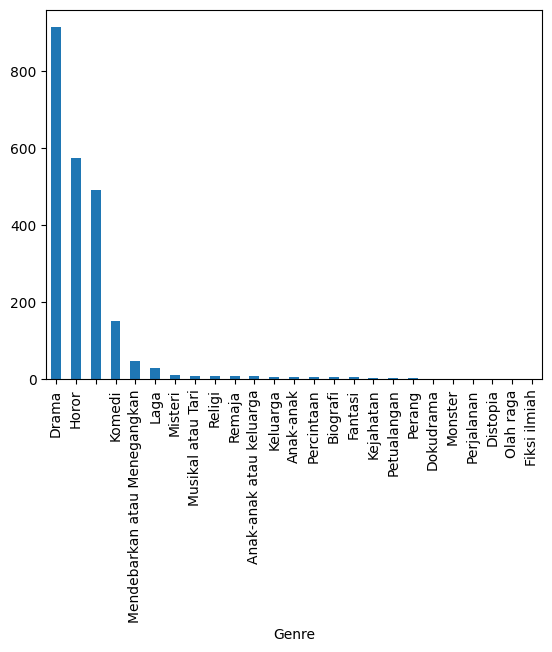

In [14]:
df["Genre"].value_counts().plot(kind="bar")

In [20]:
df[df['Genre'] == ''].shape[0]

492

<Axes: xlabel='Tahun'>

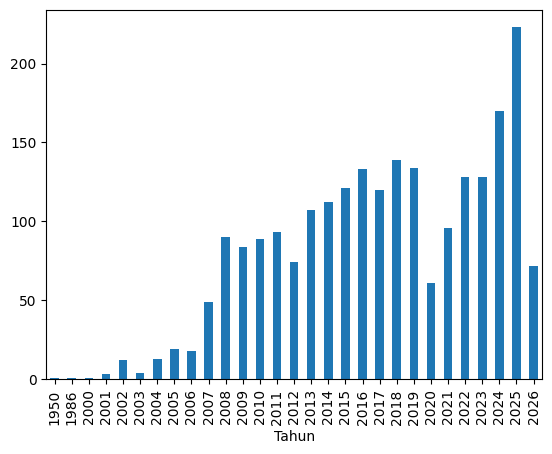

In [30]:
df["Tahun"].value_counts().sort_index().plot(kind="bar")

In [31]:
df['Tahun'] = pd.to_numeric(df['Tahun'], errors='coerce')
df_2023plus = df[df['Tahun'] == 2025]
genre_counts = df_2023plus['Genre'].value_counts()
print(genre_counts.to_string())

Genre
Horor                           92
Drama                           91
Religi                           7
Komedi                           6
Mendebarkan atau Menegangkan     5
Percintaan                       4
Misteri                          4
Musikal atau Tari                3
Fantasi                          3
Remaja                           2
Kejahatan                        1
Anak-anak                        1
Keluarga                         1
Dokudrama                        1
Perang                           1
Monster                          1


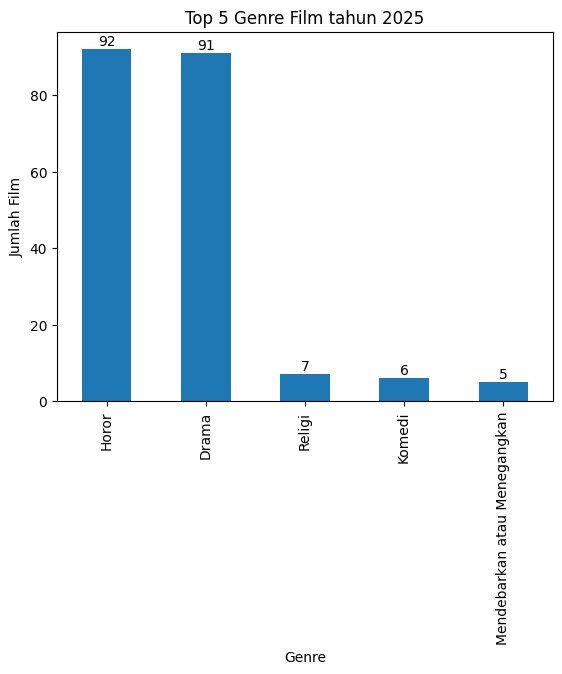

In [33]:
import matplotlib.pyplot as plt

df_2025 = df[df["Tahun"] == 2025]
top_genre = df_2025["Genre"].value_counts().head(5)
top_genre.plot(kind="bar")
plt.title("Top 5 Genre Film tahun 2025")
plt.xlabel("Genre")
plt.ylabel("Jumlah Film")
for i, value in enumerate(top_genre.values):
    plt.text(i, value + 1, str(value), ha='center')
plt.show()